<a href="https://colab.research.google.com/github/inteliun/PRESENTACIONES/blob/main/reloj_mundial.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

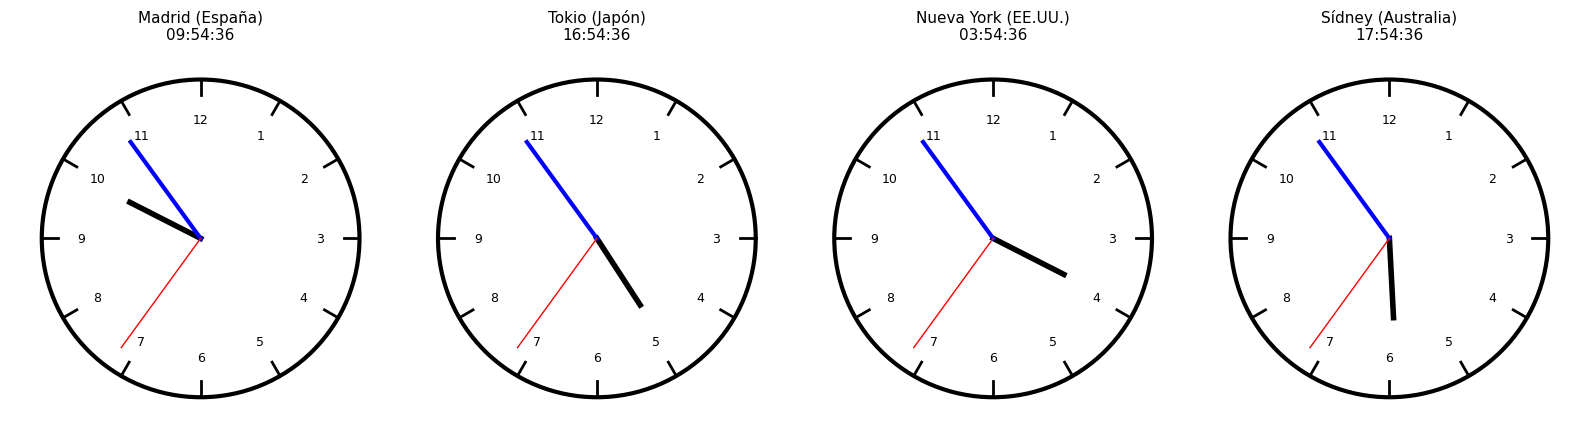

In [ ]:
import matplotlib.pyplot as plt
import numpy as np
from datetime import datetime
from zoneinfo import ZoneInfo
from IPython.display import clear_output
import time
import math

# Ciudades/países elegidos para cubrir el planeta
ciudades = [
    ("Madrid (España)", "Europe/Madrid"),
    ("Tokio (Japón)", "Asia/Tokyo"),
    ("Nueva York (EE.UU.)", "America/New_York"),
    ("Sídney (Australia)", "Australia/Sydney"),
]

def dibujar_reloj(ax, hora, minuto, segundo, titulo):
    ax.clear()
    ax.set_xlim(-1.2, 1.2)
    ax.set_ylim(-1.2, 1.2)
    ax.set_aspect('equal')
    ax.axis('off')

    # Círculo del reloj
    circulo = plt.Circle((0, 0), 1, fill=False, linewidth=3, color='black')
    ax.add_artist(circulo)

    # Marcas de las horas
    for i in range(12):
        ang = math.radians(90 - i * 30)
        x1, y1 = 0.9 * math.cos(ang), 0.9 * math.sin(ang)
        x2, y2 = math.cos(ang), math.sin(ang)
        ax.plot([x1, x2], [y1, y2], color='black', linewidth=2)
        xt, yt = 0.75 * math.cos(ang), 0.75 * math.sin(ang)
        ax.text(xt, yt, str(i if i != 0 else 12), ha='center', va='center', fontsize=9)

    # Ángulos de las agujas
    ang_h = math.radians(90 - (hora % 12 + minuto / 60) * 30)
    ang_m = math.radians(90 - minuto * 6)
    ang_s = math.radians(90 - segundo * 6)

    # Aguja horas
    ax.plot([0, 0.5 * math.cos(ang_h)], [0, 0.5 * math.sin(ang_h)], color='black', linewidth=4)
    # Aguja minutos
    ax.plot([0, 0.75 * math.cos(ang_m)], [0, 0.75 * math.sin(ang_m)], color='blue', linewidth=3)
    # Aguja segundos
    ax.plot([0, 0.85 * math.cos(ang_s)], [0, 0.85 * math.sin(ang_s)], color='red', linewidth=1)

    ax.set_title(f"{titulo}\n{hora:02d}:{minuto:02d}:{segundo:02d}", fontsize=11)

# Bucle de actualización en vivo
try:
    while True:
        fig, axs = plt.subplots(1, 4, figsize=(16, 4.5))
        for ax, (nombre, tz) in zip(axs, ciudades):
            ahora = datetime.now(ZoneInfo(tz))
            dibujar_reloj(ax, ahora.hour, ahora.minute, ahora.second, nombre)

        clear_output(wait=True)
        plt.tight_layout()
        plt.show()
        time.sleep(1)
except KeyboardInterrupt:
    print("Reloj detenido.")